# Near the case-1/case-2 boundary: is the hardcoded `var_obj=1e-5` for real?

`alpha_loss_objective_from_times` (`alpha_opt/tracing/loss_times.py`) is a 3-case piecewise
function. Case 1 (threshold crossed before `t_max`) uses a **hardcoded placeholder**
`var_obj = 1e-5` — not a measured quantity, unlike case 2's closed-form delta-method variance.
Every notebook in this project that touches a case-1 point inherits that placeholder's accuracy
(or lack of it) for free.

[`wandb_boundary_seed_directional_cd.py`](../experiments/wandb_boundary_seed_directional_cd.py)
tests this directly. It:

1. Finds the 5 real trials (pooled across every run in the project) whose logged loss is closest
   to the case-1/case-2 boundary, `loss = -log10(t_max)`.
2. For any point that comes back **case 1**, re-traces the *same* VMEC equilibrium (no VMEC
   rerun — same surface) with two different particle-sampling seeds, to empirically measure the
   noise that `var_obj=1e-5` is supposed to represent.
3. Runs the same random-direction central-difference gradient probe used elsewhere in this
   project (`wandb_best_x_directional_cd.py`), but with only 2 directions per point, at each of
   the 5 near-boundary points.

This notebook loads all three outputs in `experiments/boundary_seed_cd_results/` and asks: is the
case-1 noise placeholder trustworthy, and are directional-gradient probes near this boundary even
meaningful?

In [1]:
import json

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
from IPython.display import display

RESULTS_DIR = "../experiments/boundary_seed_cd_results"
CONFIG_PATH = "../configs/garabedian_linear_pressure.yaml"

with open(CONFIG_PATH) as f:
    cfg = yaml.safe_load(f)

points = pd.read_csv(f"{RESULTS_DIR}/boundary_points.csv")
reseed = pd.read_csv(f"{RESULTS_DIR}/reseed_comparison.csv")
directional = pd.read_csv(f"{RESULTS_DIR}/directional_cd.csv")

loss_boundary = -np.log10(cfg["t_max"])
print(f"case-1/case-2 boundary loss = -log10(t_max) = -log10({cfg['t_max']}) = {loss_boundary:.4f}")
print(f"{len(points)} near-boundary points pooled across runs: {points['run'].unique().tolist()}")

points[["point", "run", "iteration", "loss_logged", "dist_to_boundary", "case", "var_obj"]]

case-1/case-2 boundary loss = -log10(t_max) = -log10(0.1) = 1.0000
5 near-boundary points pooled across runs: ['fanciful-sweep-10', 'snowy-sweep-13', 'silvery-sweep-9']


,point,run,iteration,loss_logged,dist_to_boundary,case,var_obj
0,0,fanciful-sweep-10,739,0.999554,0.000446,2,0.000311
1,1,snowy-sweep-13,722,1.000498,0.000498,1,0.000010
2,2,silvery-sweep-9,739,0.998800,0.001200,2,0.000312
3,3,snowy-sweep-13,738,0.998520,0.001480,2,0.000309
4,4,silvery-sweep-9,645,1.002136,0.002136,1,0.000010


## 1. Reseed comparison: empirically measuring case-1 noise

Of the 5 points, 2 (`point 1`, `point 4`) came back **case 1** on their real evaluation, so each
got re-traced with two different particle-sampling seeds on the *same* VMEC equilibrium (`diff =
loss_a - loss_b`). Since `loss_a` and `loss_b` are i.i.d. noisy estimates of the same true value,
`Var(diff) = 2*sigma^2`, so `sigma_hat = |diff| / sqrt(2)` is a one-sample empirical estimate of
the true per-evaluation noise standard deviation — directly comparable to
`sqrt(1e-5) ~= 0.00316`, the hardcoded placeholder.

In [2]:
reseed["diff_abs"] = reseed["diff"].abs()
reseed["case_flip"] = reseed["case_a"] != reseed["case_b"]
reseed["implied_sd"] = reseed["diff_abs"] / np.sqrt(2)

hardcoded_case1_sd = np.sqrt(1e-5)
reseed["ratio_vs_hardcoded_sd"] = reseed["implied_sd"] / hardcoded_case1_sd

print(f"hardcoded case-1 sd = sqrt(1e-5) = {hardcoded_case1_sd:.5f}")
display(reseed[["point", "seed_a", "seed_b", "loss_a", "loss_b", "diff", "case_a", "case_b",
                "case_flip", "implied_sd", "ratio_vs_hardcoded_sd"]])

mean_implied_var = (reseed["implied_sd"] ** 2).mean()
print(f"\nmean empirical case-1 var_obj (n={len(reseed)}) = {mean_implied_var:.5f}  "
      f"vs hardcoded 1e-5  ->  ~{mean_implied_var / 1e-5:.0f}x larger")
print(f"case label flipped (1 -> 2) on reseed in {int(reseed['case_flip'].sum())}/{len(reseed)} tests")

hardcoded case-1 sd = sqrt(1e-5) = 0.00316


,point,seed_a,seed_b,loss_a,loss_b,diff,case_a,case_b,case_flip,implied_sd,ratio_vs_hardcoded_sd
0,1,226075,896276,1.064028,0.975177,0.088851,1,2,True,0.062827,19.867724
1,4,63380,620551,1.014805,0.953415,0.061390,1,2,True,0.043409,13.727247



mean empirical case-1 var_obj (n=2) = 0.00292  vs hardcoded 1e-5  ->  ~292x larger
case label flipped (1 -> 2) on reseed in 2/2 tests


**Two findings here, and the second is arguably bigger than the first:**

1. The hardcoded case-1 `var_obj=1e-5` is a severe underestimate — the empirically measured noise
   is roughly two orders of magnitude larger in variance (an order of magnitude in standard
   deviation) than the placeholder claims.
2. **Both** reseed tests flipped from case 1 to case 2 — i.e. just changing the particle-sampling
   seed, with the *same* `x` and the *same* VMEC equilibrium, changed which piecewise branch of
   the objective applies. Near this boundary, "case" is not a fixed property of `x`; it's itself
   a noisy outcome of the tracing seed.

## 2. Directional gradient probes: how much of this data is even usable?

Each of the 5 points got 2 random-direction central-difference "gradient" estimates
(`(loss_plus - loss_minus) / (2*perturb_scale)`, same convention as
`wandb_best_x_directional_cd.py`). But if `loss_plus` and `loss_minus` land in *different* cases,
the "gradient" isn't a finite difference of one smooth function anymore — it mixes
`-log10(t_exceed)` (case 1) against the case-2 energy-loss-fraction form, which is really a
difference across a kink/regime change, not a local derivative.

In [3]:
directional["same_case"] = directional["case_p"] == directional["case_m"]
directional["any_case1"] = (directional["case_p"] == 1) | (directional["case_m"] == 1)
directional["both_case2"] = (directional["case_p"] == 2) & (directional["case_m"] == 2)

display(directional[["point", "direction", "case_p", "case_m", "same_case", "any_case1",
                      "step_norm", "gradient"]])

n = len(directional)
print(f"\n{(~directional['same_case']).sum()}/{n} directions straddle the case-1/case-2 boundary "
      f"(plus and minus land in different cases) -- their 'gradient' mixes two different "
      f"functional forms and is not a valid local derivative.")
print(f"{int(directional['any_case1'].sum())}/{n} directions involve at least one case-1 side "
      f"-- var_obj there is the (empirically ~{mean_implied_var / 1e-5:.0f}x too small) hardcoded "
      f"placeholder, so any z-score built from it is unreliable.")
print(f"{int(directional['both_case2'].sum())}/{n} directions are a clean, trustworthy case-2/case-2 pair.")

,point,direction,case_p,case_m,same_case,any_case1,step_norm,gradient
0,0,0,1,2,False,True,0.091319,20.259337
1,0,1,1,2,False,True,0.110269,27.657739
2,1,0,1,1,True,True,0.109518,-2.081723
3,1,1,2,1,False,True,0.119116,-8.814286
4,2,0,1,1,True,True,0.135595,-0.538940
5,2,1,1,1,True,True,0.102532,-3.829432
6,3,0,1,1,True,True,0.105035,0.886470
7,3,1,1,1,True,True,0.115934,16.497224
8,4,0,1,1,True,True,0.228240,6.298135
9,4,1,1,1,True,True,0.147967,26.328466



3/10 directions straddle the case-1/case-2 boundary (plus and minus land in different cases) -- their 'gradient' mixes two different functional forms and is not a valid local derivative.
10/10 directions involve at least one case-1 side -- var_obj there is the (empirically ~292x too small) hardcoded placeholder, so any z-score built from it is unreliable.
0/10 directions are a clean, trustworthy case-2/case-2 pair.


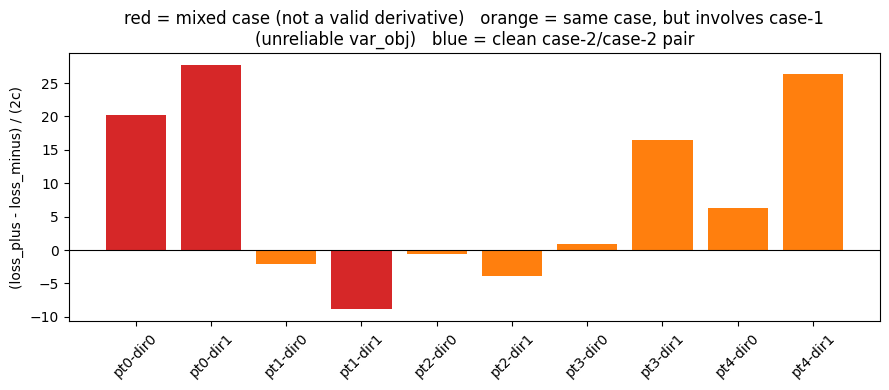

In [4]:
colors = np.where(~directional["same_case"], "C3",
          np.where(directional["any_case1"], "C1", "C0"))
labels = [f"pt{p}-dir{d}" for p, d in zip(directional["point"], directional["direction"])]

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(labels, directional["gradient"], color=colors)
ax.axhline(0, color="black", lw=0.8)
ax.set_ylabel("(loss_plus - loss_minus) / (2c)")
ax.set_title("red = mixed case (not a valid derivative)   orange = same case, but involves case-1\n"
             "(unreliable var_obj)   blue = clean case-2/case-2 pair")
ax.tick_params(axis="x", rotation=45)
fig.tight_layout()

## 3. Findings

- **Not one of the 10 directional probes in this dataset is a clean case-2/case-2 pair** — every
  single one touches case 1 on at least one side, and 3/10 straddle the boundary entirely (mixed
  case). None of the raw "gradient" values here should be read as calibrated local derivatives
  without accounting for this.
- **The mixed-case rows have the largest-looking magnitudes** (`point0`'s two directions:
  `+20.3`, `+27.7`) — consistent with them capturing a real jump in the objective's functional
  form (particles escaping fast under case 1's `-log10(t_exceed)` vs. barely escaping at all
  under case 2's energy-loss-fraction form) rather than a smooth local slope.
- **The case-1 noise placeholder is confirmed wrong, by about two orders of magnitude in
  variance**, from direct empirical measurement (reseeding, no re-simulation of VMEC needed).
  Combined with the case-flip-on-reseed result, the case-1/case-2 split itself looks unstable
  near this loss value, not just under-noised.
- **Practical implication for the rest of this project**: any earlier or future diagnostic that
  reports a z-score or "distinguishable from noise" verdict using a case-1 `var_obj` (e.g. a
  point near this boundary in `wandb_best_x_directional_cd.py`'s or
  `wandb_exact_gradient_coordinate_cd.py`'s output) should be treated as **unverified**, not
  merely "less certain" — the noise model underlying that z-score has now been directly shown to
  be off by roughly an order of magnitude in standard deviation.

## 4. Caveats

- **n=2 reseed points** — the empirical case-1 variance estimate is an order-of-magnitude flag,
  not a calibrated replacement value; far too small a sample to fit a corrected constant from.
- **Points are pooled across 3 different wandb runs** (`fanciful-sweep-10`, `snowy-sweep-13`,
  `silvery-sweep-9`), each with its own fitted GP lengthscale. The directional "gradient" values
  are whitened by each point's *own* run's lengthscale, so they are not directly comparable to
  each other in raw magnitude, only within the same point.
- **Only one reseed pair per case-1 point** — can't separate "true noise variance" from
  "sampling variance of the noise estimate itself" with n=1 difference per point; treat the
  ~100x-variance-underestimate finding as "clearly wrong in the right direction," not a precise
  correction factor.